In [50]:
import sys
import time
import os
import glob

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import rapids_singlecell as rsc
import pandas as pd
import numpy as np

# Enable `managed_memory`
import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# load hippo-pathway

In [7]:
# from GO
filepath = "../../resources/GO_Biological_Process_2023.txt"

def search_dict_keys(d, query):
    return {k: v for k, v in d.items() if query.lower() in k.lower()}

def load_gene_sets_from_file(filepath):
    gene_sets = {}
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if parts and parts[0]:
                name = parts[0].strip()
                genes = [gene for gene in parts[1:] if gene]
                gene_sets[name] = genes
    return gene_sets

gene_sets = load_gene_sets_from_file(filepath)
print(len(gene_sets))

query = "hippo"
pathways = search_dict_keys(gene_sets, query)
list(pathways.keys())

5407


['Hippo Signaling (GO:0035329)',
 'Negative Regulation Of Hippo Signaling (GO:0035331)',
 'Positive Regulation Of Hippo Signaling (GO:0035332)',
 'Regulation Of Hippo Signaling (GO:0035330)']

In [9]:
key = 'Hippo Signaling (GO:0035329)'
gene_list = gene_sets[key]
print(f"number of genes: {len(gene_list)}")
print(gene_list)

number of genes: 17
['WWTR1', 'YAP1', 'MOB1A', 'SAV1', 'STK3', 'STK4', 'LATS2', 'LATS1', 'MOB1B', 'AMOTL1', 'FAT4', 'AMOTL2', 'DCHS1', 'TEAD1', 'TEAD2', 'TEAD3', 'TEAD4']


# load differentially expressed genes

In [16]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hematokytos/sample_1_adata_basename_deg.parquet"

df = pd.read_parquet(fpath)
print(f"Raw data shape: {df.shape=}")
df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# pathway genes 
df = df[df['names'].isin(gene_list)]

# upregulated only
df = df[df['logfoldchanges'] > 1.0]
print(f"Filtered data shape: {df.shape=}")

df.head()

Raw data shape: df.shape=(417312, 8)
Filtered data shape: df.shape=(24, 8)
CPU times: user 206 ms, sys: 13.5 ms, total: 219 ms
Wall time: 195 ms


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
575,endothelial_cells,TEAD4,81.584625,2.980869,0.000000e+00,0.000000e+00,0.138113,0.022527
29,endothelial_cells,WWTR1,276.311707,2.832851,0.000000e+00,0.000000e+00,0.511348,0.148571
510,endothelial_cells,SAV1,88.848869,1.399797,0.000000e+00,0.000000e+00,0.254804,0.139207
1082,endothelial_cells,DCHS1,46.880787,1.366147,0.000000e+00,0.000000e+00,0.122402,0.056177
1279,endothelial_cells,FAT4,37.559090,1.255300,1.001135e-308,1.619826e-307,0.116981,0.065342


In [28]:
outpath = "../../results/hippo.tex"
latex_df = df.copy()

columns = {
    'group': 'Cell Type',
    'names': 'Gene',
    'logfoldchanges': 'logFC',
    'pvals_adj': 'P-value (adj.)',
    'pct_nz_group': 'Pct in Group',
    'pct_nz_reference': 'Pct in Ref',
}

latex_df = latex_df[list(columns.keys())]
latex_df = latex_df.rename(columns=columns)

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    longtable=True,
    caption="Differential expression of Hippo signalling genes (GO:0035329).",
    label="tab:hippo_deg",
    column_format="llcccc"
)

print(latex_df.to_string(index=False))

with open(outpath, "w") as f:
    f.write(latex_table)

            Cell Type   Gene    logFC  P-value (adj.)  Pct in Group  Pct in Ref
    endothelial_cells  TEAD4 2.980869    0.000000e+00      0.138113    0.022527
    endothelial_cells  WWTR1 2.832851    0.000000e+00      0.511348    0.148571
    endothelial_cells   SAV1 1.399797    0.000000e+00      0.254804    0.139207
    endothelial_cells  DCHS1 1.366147    0.000000e+00      0.122402    0.056177
    endothelial_cells   FAT4 1.255300   1.619826e-307      0.116981    0.065342
    endothelial_cells  TEAD1 1.074826    0.000000e+00      0.219767    0.117533
    endothelial_cells AMOTL1 1.042113    0.000000e+00      0.147228    0.092040
          fibroblasts  TEAD3 1.697132    0.000000e+00      0.124350    0.037593
          fibroblasts   YAP1 1.431313    0.000000e+00      0.276530    0.102684
          fibroblasts AMOTL2 1.381031    0.000000e+00      0.136025    0.054155
          fibroblasts   FAT4 1.309182    0.000000e+00      0.149065    0.058405
          fibroblasts AMOTL1 1.132223   

In [29]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hematokytos/sample_1_adata_cell_type_deg.parquet"

df = pd.read_parquet(fpath)
print(f"Raw data shape: {df.shape=}")
df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# pathway genes 
df = df[df['names'].isin(gene_list)]

# upregulated only
df = df[df['logfoldchanges'] > 1.0]
print(f"Filtered data shape: {df.shape=}")

df.head()

Raw data shape: df.shape=(6103188, 8)
Filtered data shape: df.shape=(293, 8)
CPU times: user 3.86 s, sys: 779 ms, total: 4.64 s
Wall time: 4.06 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
294,B-2 B cell,STK4,18.448940,1.404448,5.317687e-76,8.834135e-74,0.658399,0.287430
373,B-2 B cell,MOB1A,15.768619,1.234014,5.115634e-56,6.540488e-54,0.611048,0.305770
469603,"CD16-negative, CD56-bright natural killer cell...",STK4,26.018631,1.787470,3.048115e-149,1.160597e-146,0.599767,0.287245
521786,"CD16-positive, CD56-dim natural killer cell, h...",STK4,86.936012,2.279365,0.000000e+00,0.000000e+00,0.712239,0.283781
522428,"CD16-positive, CD56-dim natural killer cell, h...",MOB1A,33.967548,1.039616,6.717968e-253,3.631462e-251,0.453518,0.304642


In [43]:
outpath = "../../results/hippo_genes_by_celltype.tex"

# Count hippo genes per group
latex_df = df['group'].value_counts().head(30).reset_index()
latex_df.columns = ['Cell Type', 'n Hippo Genes (up)']

# Add gene lists for each group
gene_lists = (
    df.groupby('group')['names']
    .apply(lambda x: ','.join(sorted(set(x))))
    .reset_index()
)
gene_lists.columns = ['Cell Type', 'Hippo Genes']

# Merge into the main table
latex_df = latex_df.merge(gene_lists, on='Cell Type', how='left')

# Generate LaTeX table
latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    longtable=True,
    caption="Counts of differentially expressed Hippo signalling genes (GO:0035329) by cell type.",
    label="tab:n_hippo_deg_cell_type",
    column_format="lcl"
)

# Optional: print to confirm
print(latex_df.to_string(index=False))

with open(outpath, "w") as f:
    f.write(latex_table)

                                       Cell Type  n Hippo Genes (up)                                                            Hippo Genes
                  kidney interstitial fibroblast                  12 AMOTL1,AMOTL2,FAT4,LATS1,LATS2,MOB1B,STK3,TEAD1,TEAD3,TEAD4,WWTR1,YAP1
                    endothelial cell of placenta                  11      AMOTL1,AMOTL2,DCHS1,FAT4,LATS1,LATS2,MOB1B,STK3,TEAD1,TEAD4,WWTR1
                             brain vascular cell                  11       AMOTL1,AMOTL2,FAT4,LATS1,LATS2,MOB1B,STK3,TEAD1,TEAD4,WWTR1,YAP1
                cerebral cortex endothelial cell                  11       AMOTL1,AMOTL2,FAT4,LATS1,LATS2,MOB1B,STK3,TEAD1,TEAD4,WWTR1,YAP1
                        cardiac endothelial cell                  10             AMOTL1,AMOTL2,FAT4,LATS1,LATS2,STK3,TEAD1,TEAD4,WWTR1,YAP1
                                mesothelial cell                   9                    AMOTL2,FAT4,LATS1,LATS2,STK3,TEAD1,TEAD3,TEAD4,YAP1
                fibr

# Our Data

In [45]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"
adata = sc.read_h5ad(fpath)
adata = adata[adata.obs['filter_pass'], :].copy()

adata

CPU times: user 2.66 s, sys: 6.06 s, total: 8.72 s
Wall time: 11.9 s


AnnData object with n_obs × n_vars = 20931 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    uns: 'deg', 'rank_genes_groups', 'scvi_expression', 'subgroup_colors'
    obsm: 'X_paga', 'X_pca', 'X_pca_harmony', 'X_scvi

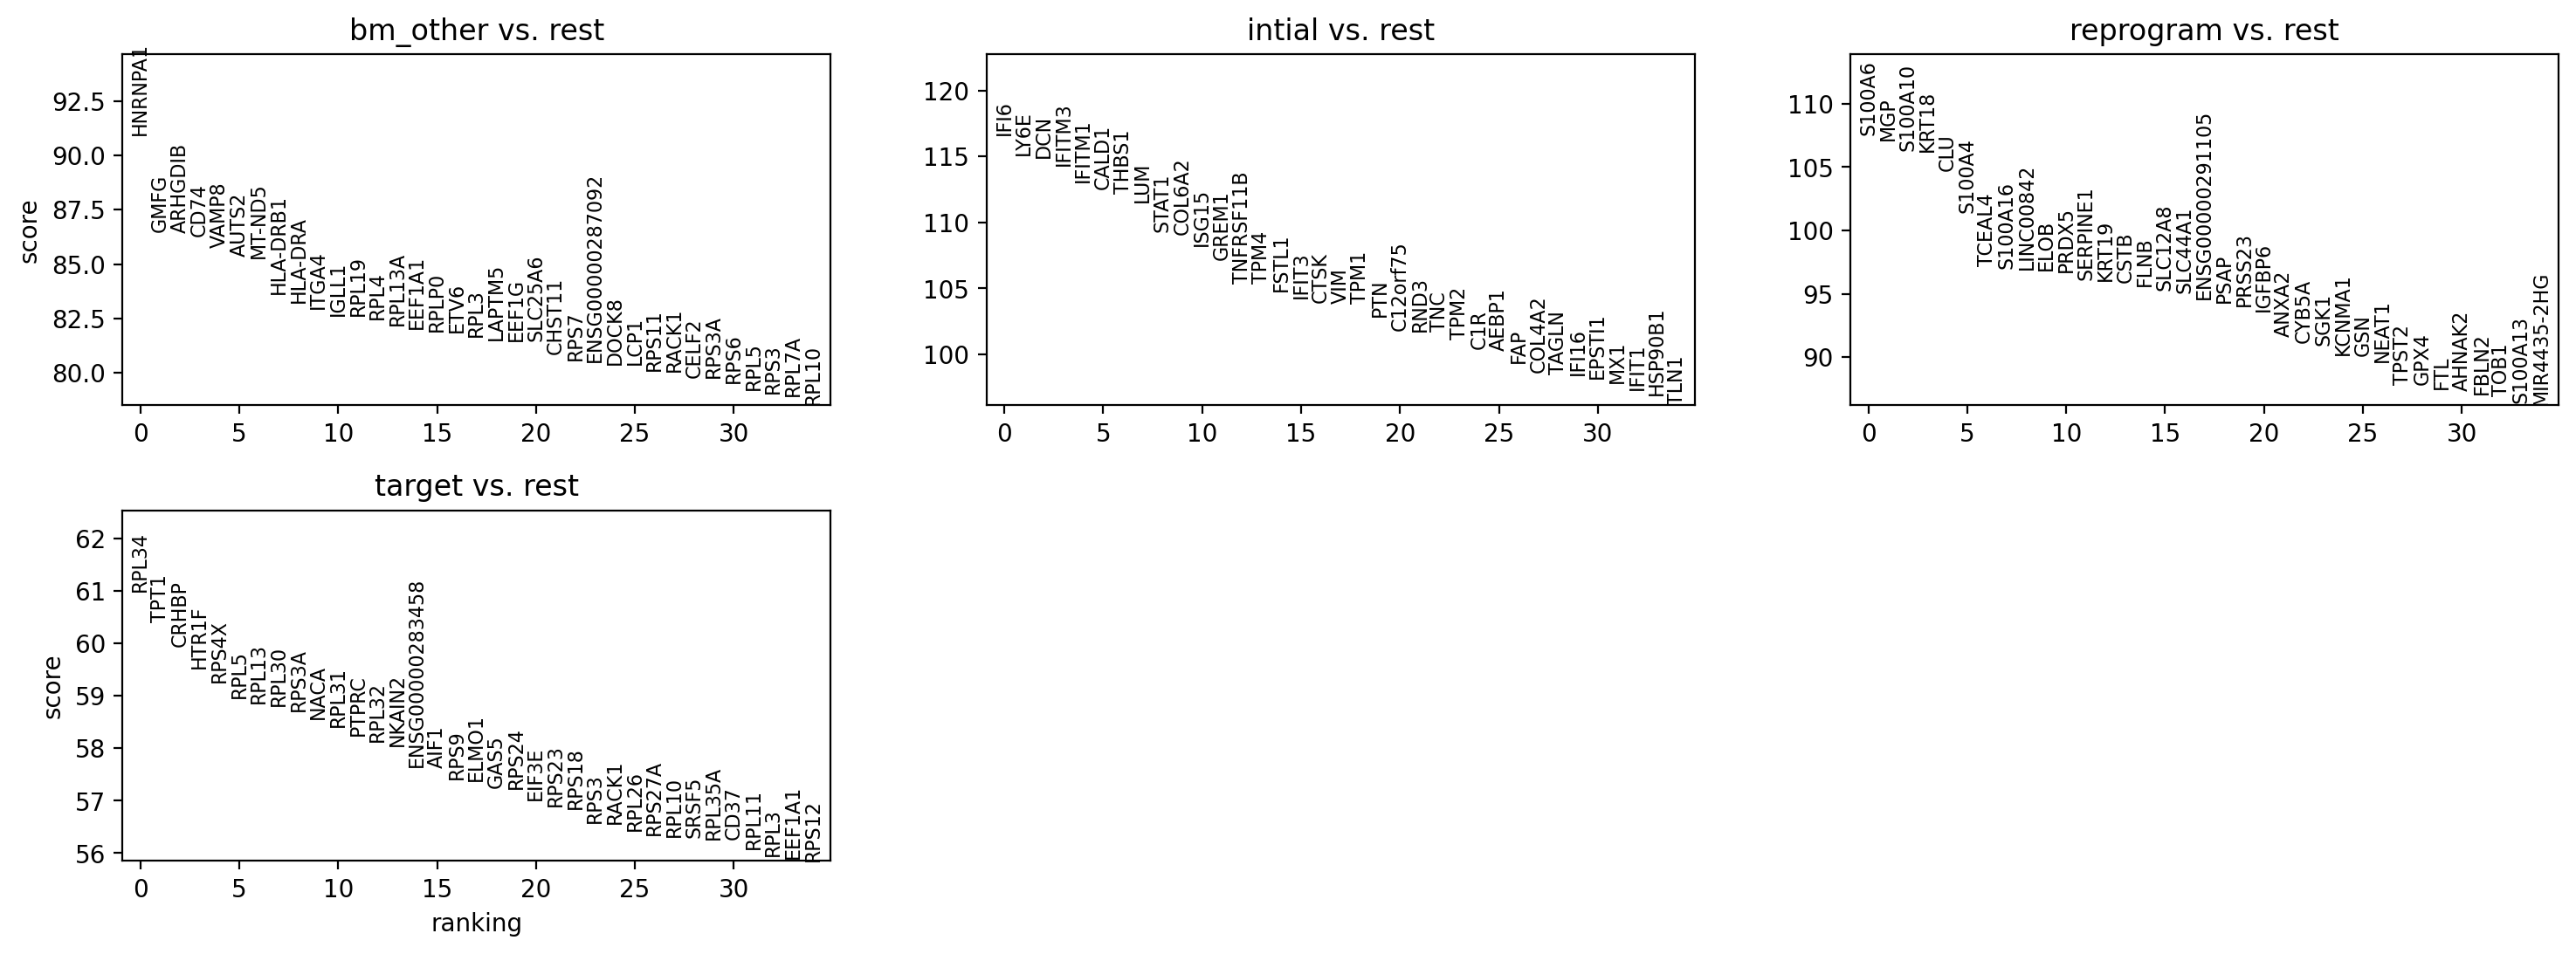

CPU times: user 41.3 s, sys: 27 s, total: 1min 8s
Wall time: 22 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,bm_other,HNRNPA1,90.918053,3.349881,0.0,0.0,0.995445,0.800047
1,bm_other,GMFG,86.474831,4.668161,0.0,0.0,0.975709,0.100713
2,bm_other,ARHGDIB,86.431465,4.913583,0.0,0.0,0.983047,0.114789
3,bm_other,CD74,86.275963,5.454658,0.0,0.0,0.985577,0.095589
4,bm_other,VAMP8,85.759254,4.691680,0.0,0.0,0.940536,0.110136


In [57]:
%%time
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
    log2fc_min=0.5,
    log2fc_max=10.0,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()

In [60]:
outpath = "../../results/hippo_genes_ourdata.tex"

df = deg.copy()
df = df.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])

# pathway genes 
df = df[df['names'].isin(gene_list)]
print(f"Filtered data shape: {df.shape=}")

outpath = "../../results/hippo_ourdata.tex"
latex_df = df.copy()

columns = {
    'group': 'Cell Type',
    'names': 'Gene',
    'logfoldchanges': 'logFC',
    'pvals_adj': 'P-value (adj.)',
    'pct_nz_group': 'Pct in Group',
    'pct_nz_reference': 'Pct in Ref',
}

latex_df = latex_df[list(columns.keys())]
latex_df = latex_df.rename(columns=columns)

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    longtable=True,
    caption="Differential expression of Hippo signalling genes (GO:0035329).",
    label="tab:hippo_deg_ourdata",
    column_format="llcccc"
)

print(latex_df.to_string(index=False))

with open(outpath, "w") as f:
    f.write(latex_table)

Filtered data shape: df.shape=(19, 8)
Cell Type   Gene    logFC  P-value (adj.)  Pct in Group  Pct in Ref
 bm_other   STK4 0.792017   1.738606e-139      0.718623    0.429707
 bm_other AMOTL1 0.562583    2.261630e-29      0.280364    0.145474
 bm_other  MOB1A 0.548460    3.269851e-81      0.804909    0.599505
 bm_other  MOB1B 0.519242    8.584290e-38      0.369433    0.207492
   intial  DCHS1 2.369790    1.929573e-06      0.053526    0.014087
   intial  TEAD1 1.676716    0.000000e+00      0.825319    0.363324
   intial  TEAD3 1.537827    7.550715e-73      0.235092    0.091145
   intial  WWTR1 1.468618    0.000000e+00      0.662299    0.294063
   intial   YAP1 1.281067   6.227616e-303      0.566796    0.256918
   intial  TEAD2 1.202039    1.058041e-32      0.174014    0.076472
   intial AMOTL2 1.006788   2.975240e-165      0.476846    0.246185
   intial  TEAD4 0.977348    1.662378e-11      0.112604    0.056683
   intial   SAV1 0.812440    1.404246e-37      0.288062    0.196462
reprogram 